In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [4]:
!pip install torchmetrics



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.5 MB/s eta 0:00:00


In [8]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = diabetes['data']
y = diabetes['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(248, 10) (111, 10) (83, 10)


In [13]:

def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch, y_batch
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)

		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch, y_batch
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, '
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)


	return history

def plot_history(history, n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 10425.615, Train Metric: 82.048, Valid Metric: 54.568
Epoch: 2/20, Loss: 4757.243, Train Metric: 57.842, Valid Metric: 58.206
Epoch: 3/20, Loss: 3860.287, Train Metric: 50.864, Valid Metric: 43.577
Epoch: 4/20, Loss: 3633.543, Train Metric: 48.358, Valid Metric: 43.681
Epoch: 5/20, Loss: 3904.249, Train Metric: 49.333, Valid Metric: 44.822
Epoch: 6/20, Loss: 3914.727, Train Metric: 51.351, Valid Metric: 43.225
Epoch: 7/20, Loss: 3473.106, Train Metric: 46.126, Valid Metric: 43.284
Epoch: 8/20, Loss: 3398.515, Train Metric: 45.778, Valid Metric: 49.877
Epoch: 9/20, Loss: 3500.505, Train Metric: 46.608, Valid Metric: 43.122
Epoch: 10/20, Loss: 3369.471, Train Metric: 46.449, Valid Metric: 47.555
Epoch: 11/20, Loss: 3314.524, Train Metric: 45.109, Valid Metric: 43.011
Epoch: 12/20, Loss: 2822.59, Train Metric: 42.406, Valid Metric: 43.209
Epoch: 13/20, Loss: 3150.727, Train Metric: 44.583, Valid Metric: 45.976
Epoch: 14/20, Loss: 2649.057, Train Metric: 40.105, Valid Me

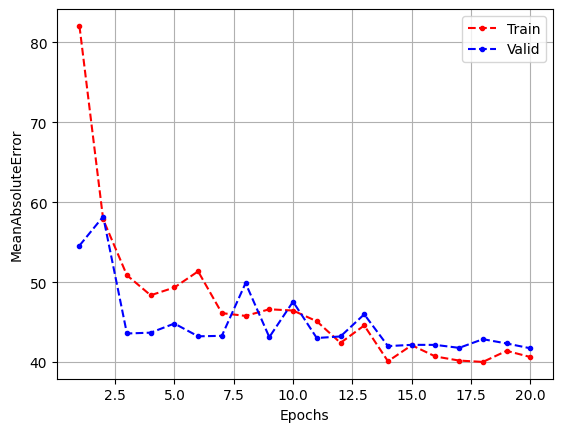

In [15]:
learning_rate = 0.01
n_epochs=20
class DiabetesRegressor(nn.Module):
    def __init__(self, n_features=10):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(in_features=n_features, out_features=30),
            nn.Sigmoid(),
            nn.Linear(in_features=30, out_features=50),
            nn.Sigmoid(),
            nn.Linear(in_features=50, out_features=1)
        )

    def forward(self, X):
        y = self.stack(X)
        return y

model = DiabetesRegressor()

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError()

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

In [18]:
model.eval()
metric.reset()
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch, y_batch
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 47.039


In [19]:
model.eval()

X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new, y_new

with torch.inference_mode():
	y_pred = model(X_new)

y_pred[:5]

tensor([[173.2393],
        [ 76.2978],
        [135.7355],
        [157.2703],
        [182.5941]])